<a href="https://colab.research.google.com/github/RizkyFirdiansyah/PCVK_Ganjil2026/blob/main/Week04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<BarContainer object of 256 artists>

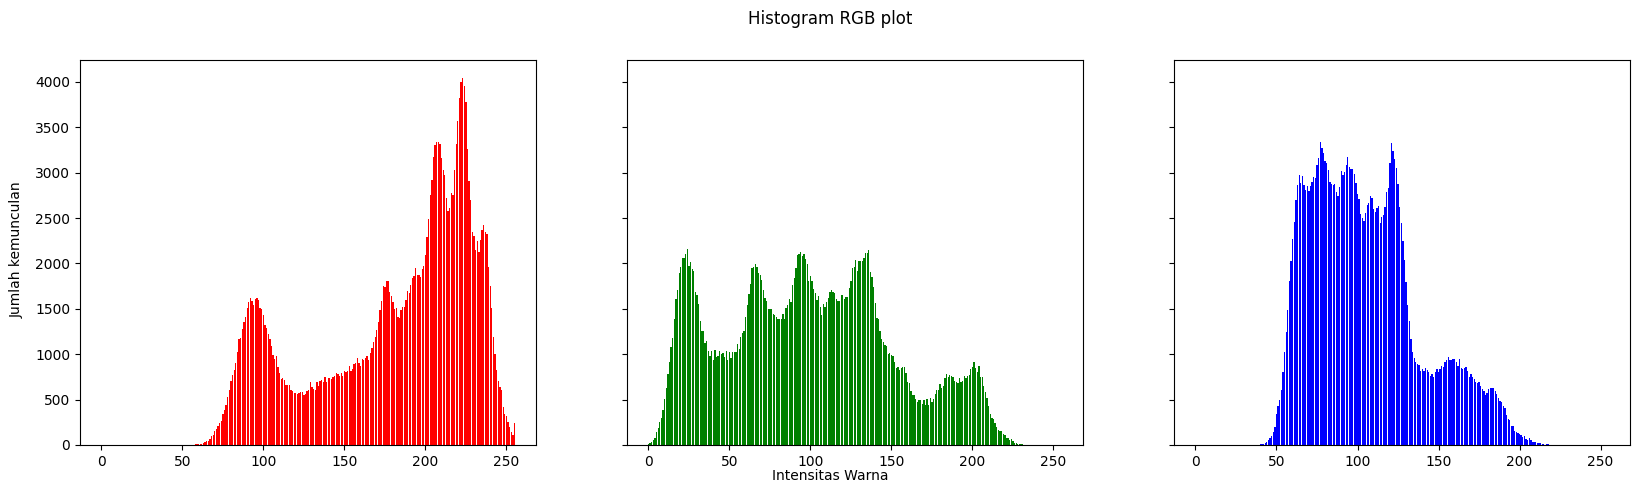

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK2026/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

In [ ]:
# Perbandingan histogram

def verify_histogram_methods(image_path):
    img = cv.imread(image_path)

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w, c = img_rgb.shape

    # Metode Manual
    hist_manual = np.zeros((3, 256), dtype=np.int64)
    for y in range(h):
        for x in range(w):
            hist_manual[0, img_rgb[y, x, 0]] += 1
            hist_manual[1, img_rgb[y, x, 1]] += 1
            hist_manual[2, img_rgb[y, x, 2]] += 1

    # Metode numpy.histogram
    hist_numpy = np.zeros((3, 256), dtype=np.int64)
    for ch in range(3):
        counts, _ = np.histogram(img_rgb[:, :, ch], bins=256, range=(0, 256))
        hist_numpy[ch] = counts

    # Metode cv.calcHist
    hist_cv = np.zeros((3, 256), dtype=np.int64)
    for ch in range(3):
        # cv.calcHist menerima list image, channel 0, mask None, histSize 256, range [0, 256]
        h_cv = cv.calcHist([img_rgb], [ch], None, [256], [0, 256])
        hist_cv[ch] = h_cv.flatten().astype(np.int64)

    # Menghitung Selisih Maksimum
    diff_manual_np = np.max(np.abs(hist_manual - hist_numpy))
    diff_manual_cv = np.max(np.abs(hist_manual - hist_cv))
    diff_np_cv = np.max(np.abs(hist_numpy - hist_cv))

    print(f"=== HASIL PEMBUKTIAN SELISIH HINGGA NIKAL BINS ({image_path}) ===")
    print(f"Selisih Maksimum (Manual vs NumPy) : {diff_manual_np}")
    print(f"Selisih Maksimum (Manual vs OpenCV): {diff_manual_cv}")
    print(f"Selisih Maksimum (NumPy vs OpenCV) : {diff_np_cv}")

    if diff_manual_np == 0 and diff_manual_cv == 0 and diff_np_cv == 0:
        print("Kesimpulan: Selisih bernilai NOL, ketiga metode menghasilkan histogram yang persis sama.\n")
    else:
        print("Kesimpulan: Selisih tidak NOL, ada metode yang menghasilkan histogram yang berbeda.\n")

# Pembuktian pada Lenna.png
verify_histogram_methods('/content/drive/MyDrive/PCVK2026/Lenna.png')

#  Pembuktian pada KTP.jpg
verify_histogram_methods('/content/drive/MyDrive/PCVK2026/ktpBlur.jpg')

=== HASIL PEMBUKTIAN SELISIH HINGGA NIKAL BINS (/content/drive/MyDrive/PCVK2026/Lenna.png) ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0
Selisih Maksimum (NumPy vs OpenCV) : 0
Kesimpulan: Selisih bernilai NOL, ketiga metode menghasilkan histogram yang persis sama.

=== HASIL PEMBUKTIAN SELISIH HINGGA NIKAL BINS (/content/drive/MyDrive/PCVK2026/ktpBlur.jpg) ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0
Selisih Maksimum (NumPy vs OpenCV) : 0
Kesimpulan: Selisih bernilai NOL, ketiga metode menghasilkan histogram yang persis sama.



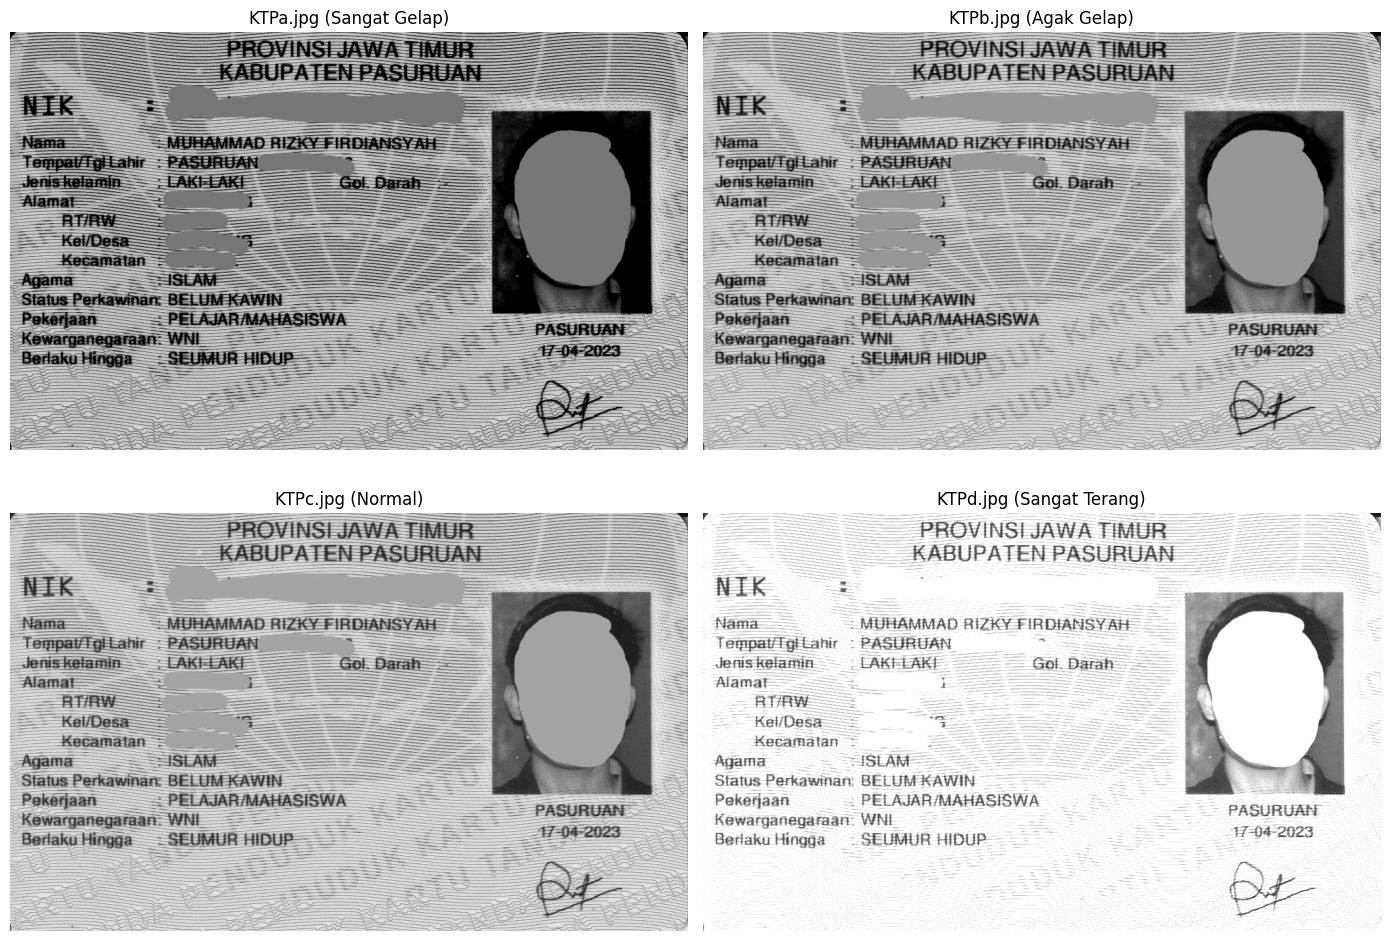

In [ ]:
path_ktp = '/content/drive/MyDrive/PCVK2026/ktpBlur.jpg'
img_base = cv.imread(path_ktp, cv.IMREAD_GRAYSCALE)

# Simulasi 4 variasi pencahayaan (ktp1a s/d ktp1d)

# 1. Sangat Gelap (Gamma 0.3 / Brightness -80)
ktp_1a = np.clip(img_base.astype(np.int16) - 90, 0, 255).astype(np.uint8)

# 2. Agak Gelap (Brightness -40)
ktp_1b = np.clip(img_base.astype(np.int16) - 40, 0, 255).astype(np.uint8)

# 3. Normal / Terang Seimbang (Kondisi Asli)
ktp_1c = img_base.copy()

# 4. Sangat Terang / Silau (Brightness +90)
ktp_1d = np.clip(img_base.astype(np.int16) + 90, 0, 255).astype(np.uint8)

dict_ktp = {
    'KTPa.jpg (Sangat Gelap)': ktp_1a,
    'KTPb.jpg (Agak Gelap)': ktp_1b,
    'KTPc.jpg (Normal)': ktp_1c,
    'KTPd.jpg (Sangat Terang)': ktp_1d
}

# Plotting 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (nama, img_data) in enumerate(dict_ktp.items()):
    axes[i].imshow(img_data, cmap='gray')
    axes[i].set_title(nama)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


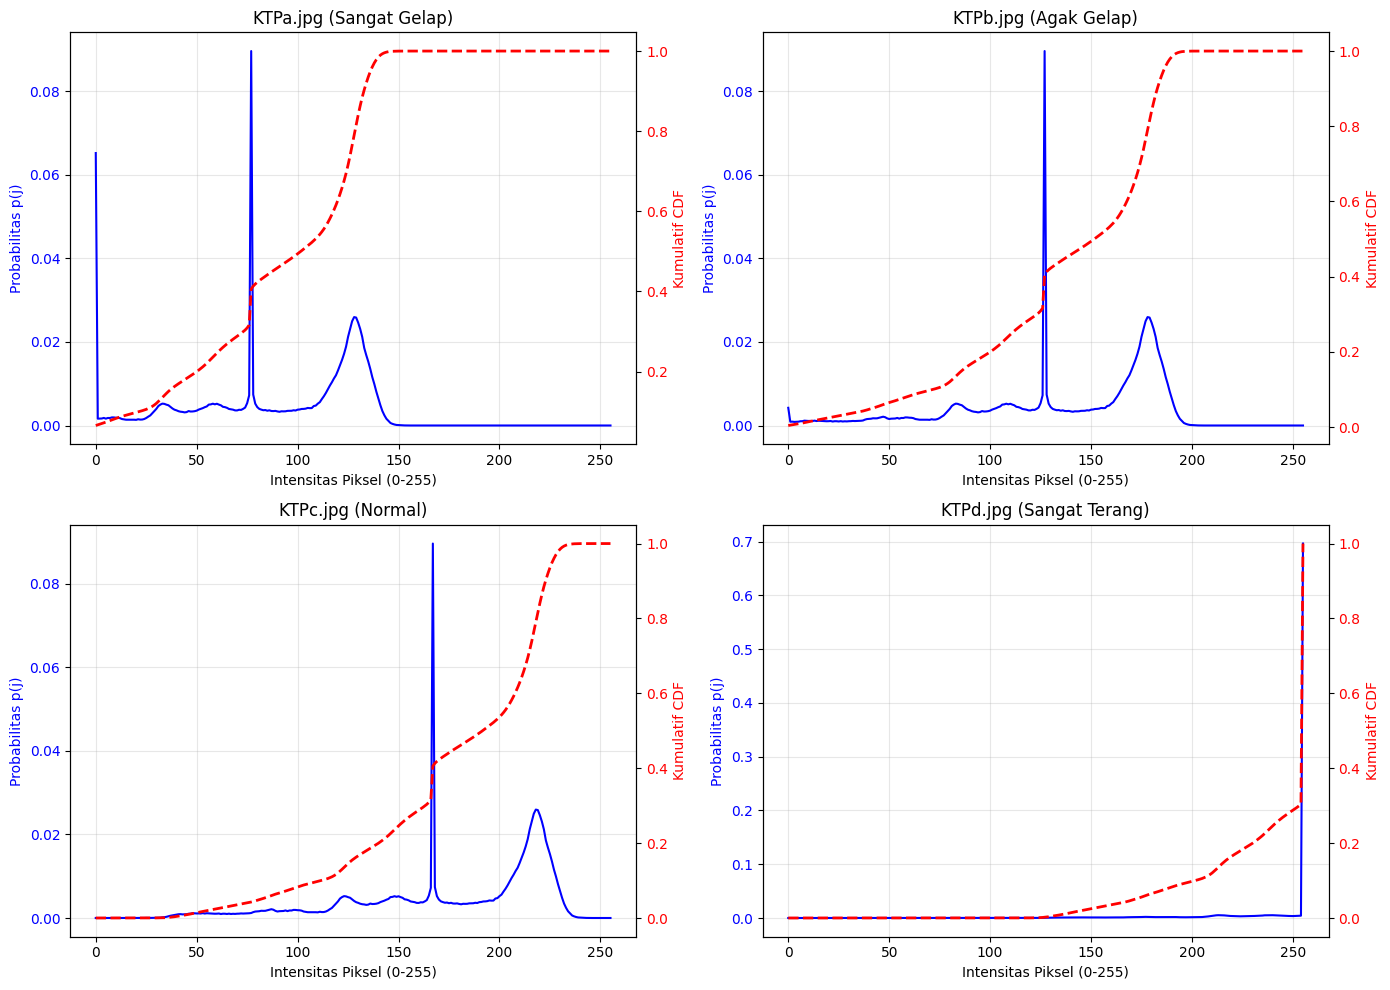

In [ ]:
# Histogram Ternormalisasi dan Perbedaan Kurva CDF

# Plotting 2x2
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
axes2 = axes2.ravel()

for idx, (title, img) in enumerate(dict_ktp.items()):
    # Hitung Histogram Raw
    hist, _ = np.histogram(img.flatten(), 256, [0, 256])

    # Histogram Ternormalisasi p(j)
    p_j = hist / float(img.size)

    # Cumulative Distribution Function (CDF)
    cdf = p_j.cumsum()

    # Sumbu Y Sekunder untuk CDF
    ax1 = axes2[idx]
    ax2 = ax1.twinx()

    # Plot p(j)
    ax1.plot(p_j, color='blue', label='p(j) Normalized Hist')
    ax1.set_xlabel('Intensitas Piksel (0-255)')
    ax1.set_ylabel('Probabilitas p(j)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Plot CDF
    ax2.plot(cdf, color='red', linestyle='--', linewidth=2, label='CDF')
    ax2.set_ylabel('Kumulatif CDF', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

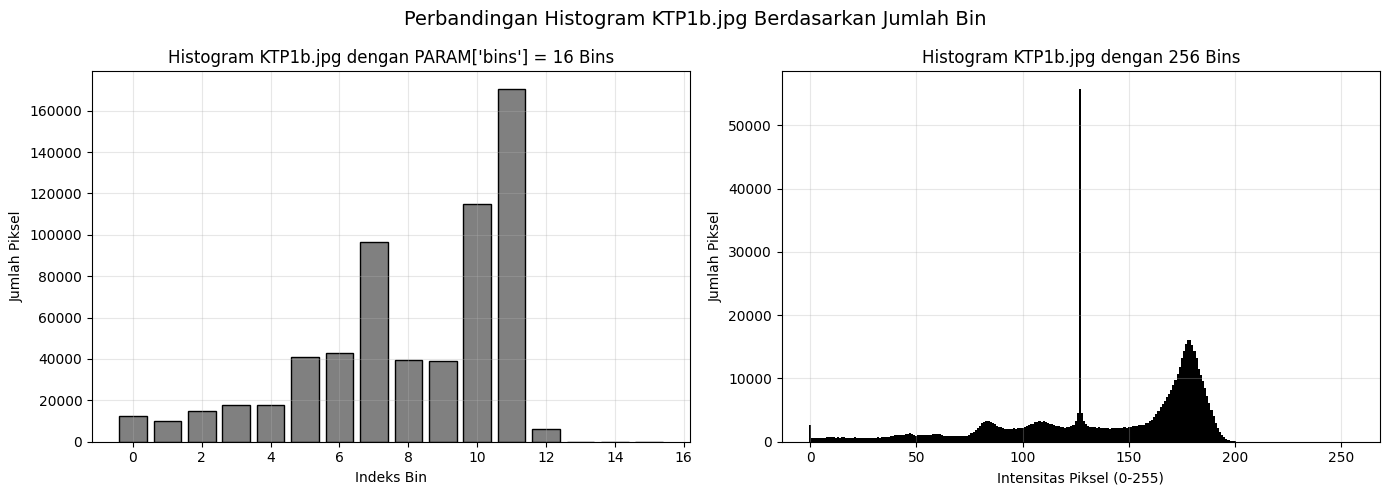

In [ ]:
# Perbandingan Bins pada KTP1b.jpg

# Tentukan parameter jumlah bin (PARAM['bins'] = 16)
PARAM = {'bins': 16}

# Menggunakan citra KTPb
img_ktp1b = dict_ktp['KTPb.jpg (Agak Gelap)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan jumlah bin sebesar PARAM['bins'] (16 Bins)
hist_param, _ = np.histogram(
    img_ktp1b.flatten(), bins=PARAM['bins'], range=[0, 256]
)
axes[0].bar(
    range(PARAM['bins']),
    hist_param,
    color='gray',
    edgecolor='black',
    width=0.8,
)
axes[0].set_title(
    f"Histogram KTP1b.jpg dengan PARAM['bins'] = {PARAM['bins']} Bins"
)
axes[0].set_xlabel('Indeks Bin')
axes[0].set_ylabel('Jumlah Piksel')
axes[0].grid(True, alpha=0.3)

# Histogram dengan 256 Bins
hist_256, _ = np.histogram(img_ktp1b.flatten(), bins=256, range=[0, 256])
axes[1].bar(range(256), hist_256, color='black', width=1.0)
axes[1].set_title('Histogram KTP1b.jpg dengan 256 Bins')
axes[1].set_xlabel('Intensitas Piksel (0-255)')
axes[1].set_ylabel('Jumlah Piksel')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Histogram KTP1b.jpg Berdasarkan Jumlah Bin', fontsize=14)
plt.tight_layout()
plt.show()

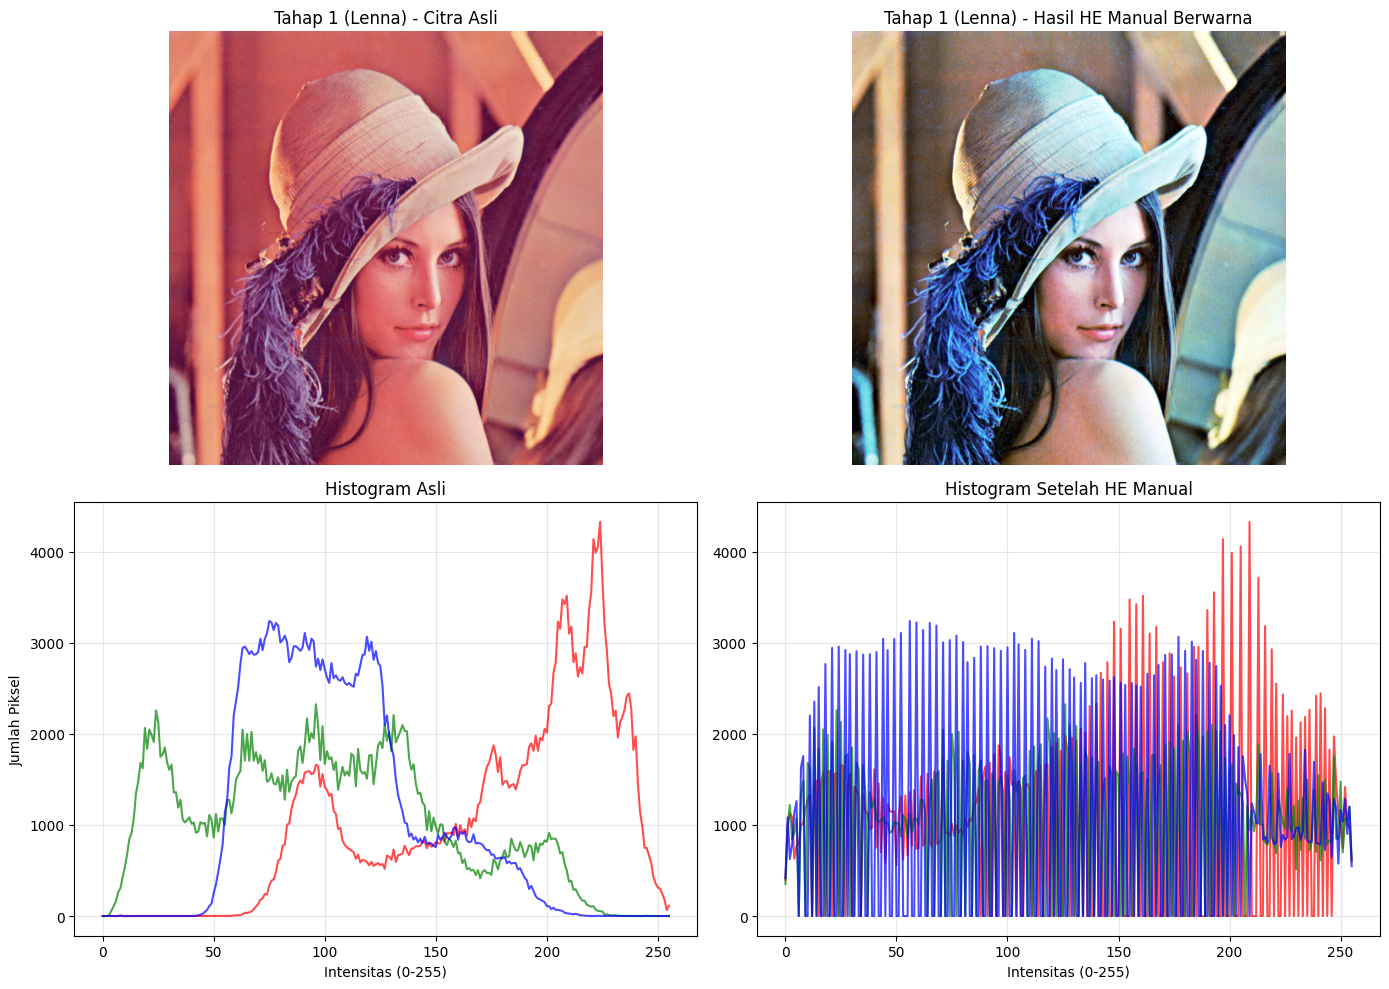

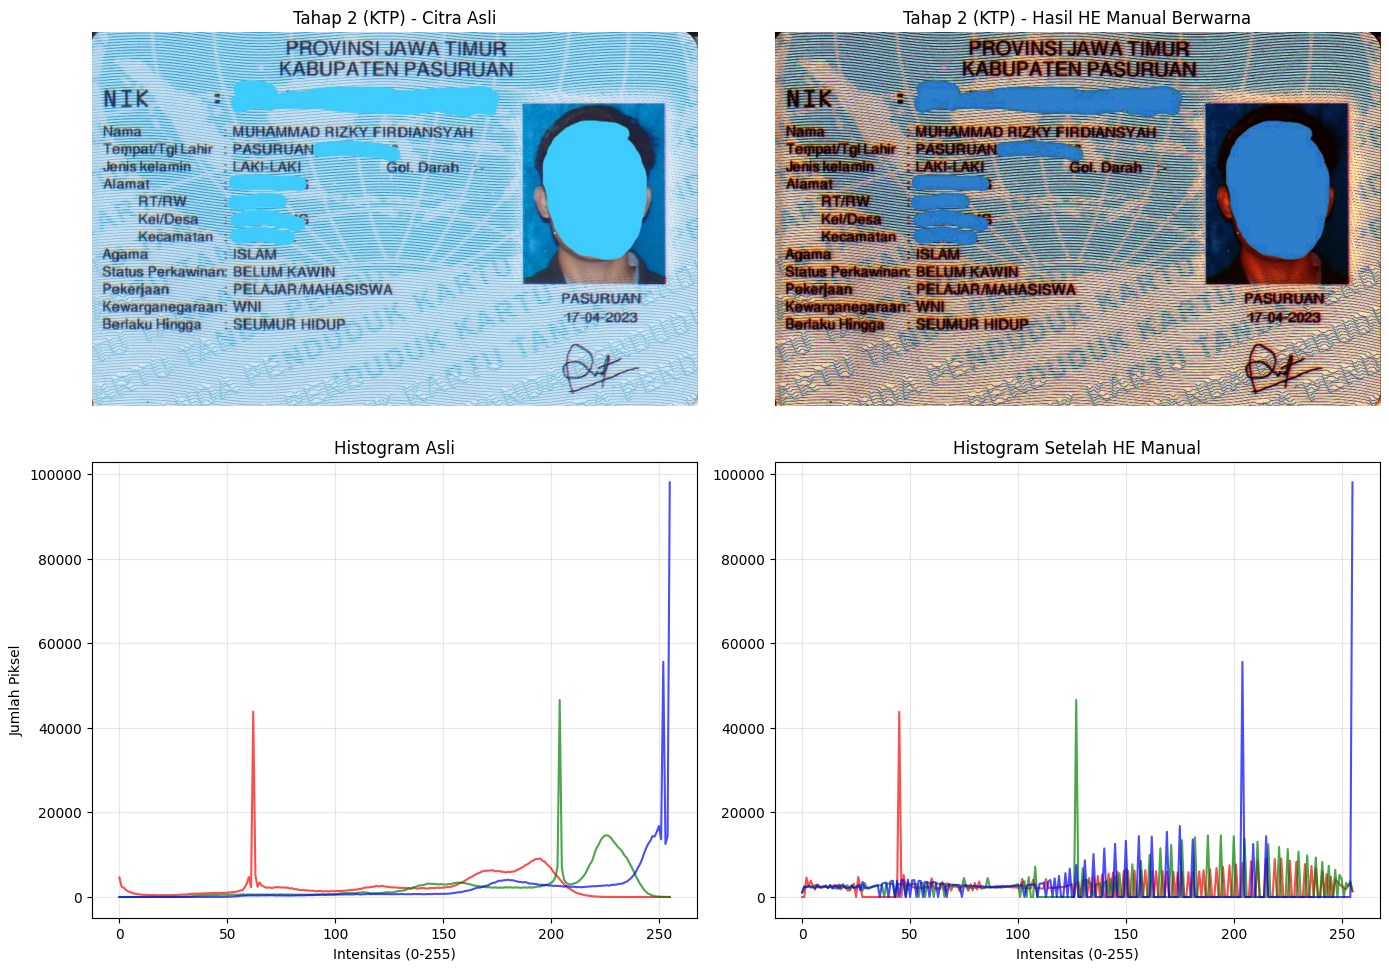

In [ ]:
# Ekualisasi Manual
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Definisikan PATH sesuai folder Anda
BASE_PATH = '/content/drive/MyDrive/PCVK2026/'

# Fungsi Histogram Equalization Manual untuk 1 Kanal
def manual_he_channel(channel):
    # 1. Hitung histogram manual
    hist = np.zeros(256, dtype=np.int64)
    h, w = channel.shape
    for y in range(h):
        for x in range(w):
            hist[channel[y, x]] += 1

    # 2. Hitung Probabilitas (PDF) dan Kumulatif (CDF)
    total_pixels = h * w
    pdf = hist / total_pixels
    cdf = np.cumsum(pdf)

    # 3. Fungsi Transformasi T(r_k) = round(255 * CDF)
    transform_map = np.round(cdf * 255).astype(np.uint8)

    # 4. Aplikasikan peta transformasi ke citra baru
    eq_channel = np.zeros_like(channel)
    for y in range(h):
        for x in range(w):
            eq_channel[y, x] = transform_map[channel[y, x]]

    return eq_channel

# Fungsi utama untuk memproses citra berwarna dan menampilkan hasilnya
def process_and_plot_color_he(filename, title_prefix):
    # BACA CITRA BERWARNA
    img_bgr = cv.imread(BASE_PATH + filename)

    # Konversi BGR ke RGB untuk Matplotlib
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # Pisahkan kanal warna R, G, B
    r, g, b = cv.split(img_rgb)

    # Terapkan HE Manual pada masing-masing kanal
    r_eq = manual_he_channel(r)
    g_eq = manual_he_channel(g)
    b_eq = manual_he_channel(b)

    # Gabungkan kembali menjadi citra RGB yang terekualisasi
    img_eq_rgb = cv.merge([r_eq, g_eq, b_eq])

    # PLOTTING
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = ('red', 'green', 'blue')

    # 1. Tampilkan Citra Asli
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title(f'{title_prefix} - Citra Asli')
    axes[0, 0].axis('off')

    # 2. Tampilkan Citra Hasil HE Manual
    axes[0, 1].imshow(img_eq_rgb)
    axes[0, 1].set_title(f'{title_prefix} - Hasil HE Manual Berwarna')
    axes[0, 1].axis('off')

    # 3. Tampilkan Histogram Citra Asli
    for i, col in enumerate(colors):
        hist_asli = cv.calcHist([img_rgb], [i], None, [256], [0, 256])
        axes[1, 0].plot(hist_asli, color=col, alpha=0.7)
    axes[1, 0].set_title('Histogram Asli')
    axes[1, 0].set_xlabel('Intensitas (0-255)')
    axes[1, 0].set_ylabel('Jumlah Piksel')
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Tampilkan Histogram Hasil HE
    for i, col in enumerate(colors):
        hist_eq = cv.calcHist([img_eq_rgb], [i], None, [256], [0, 256])
        axes[1, 1].plot(hist_eq, color=col, alpha=0.7)
    axes[1, 1].set_title('Histogram Setelah HE Manual')
    axes[1, 1].set_xlabel('Intensitas (0-255)')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Tahap 1: Citra Lenna.png
process_and_plot_color_he('Lenna.png', 'Tahap 1 (Lenna)')

# Tahap 2: Citra ktpBlur.jpg
process_and_plot_color_he('ktpBlur.jpg', 'Tahap 2 (KTP)')


--- Evaluasi Citra: Lenna.png ---
Selisih maksimum HE Manual vs cv.equalizeHist: 0


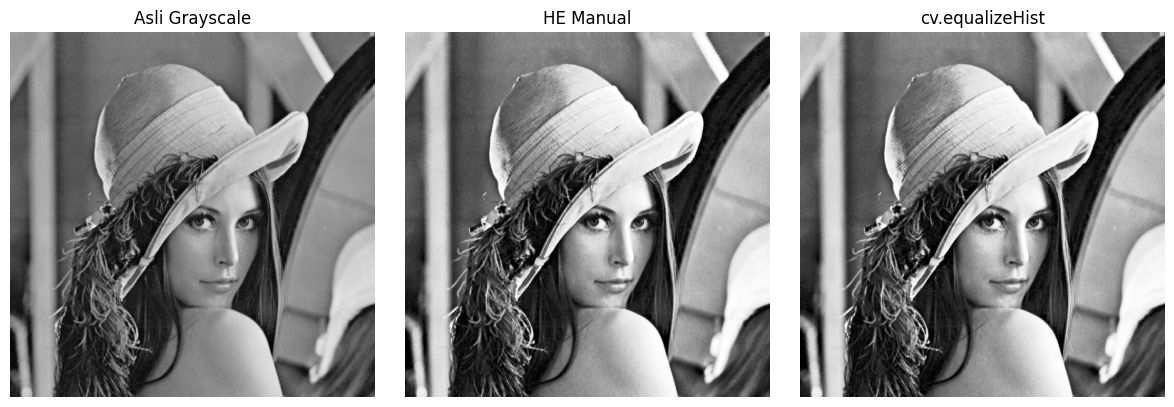


--- Evaluasi Citra: ktpBlur.jpg ---
Selisih maksimum HE Manual vs cv.equalizeHist: 0


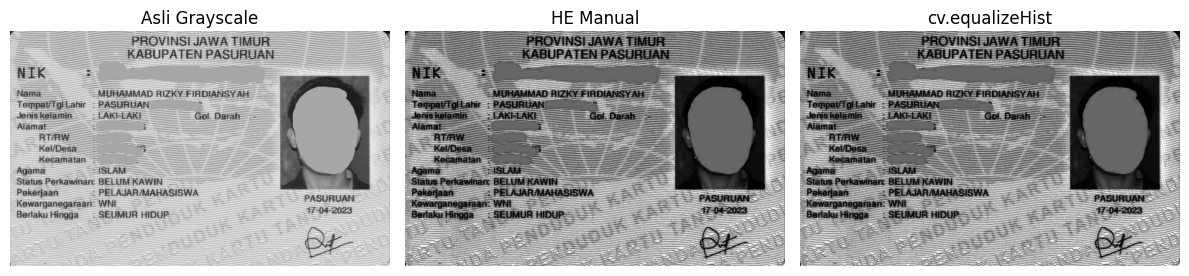

In [ ]:
# Perbandingan HE Manual vs OpenCV
def compare_equalizeHist(filename):
    print(f"\n--- Evaluasi Citra: {filename} ---")
    img_bgr = cv.imread(BASE_PATH + filename)

    if img_bgr is None:
        print("Citra tidak ditemukan!")
        return

    # Ubah ke grayscale untuk pengujian algoritma dasar
    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    # 1. Ekualisasi Manual
    manual_eq = manual_he_channel(img_gray)

    # 2. Ekualisasi OpenCV
    cv2_eq = cv.equalizeHist(img_gray)

    # 3. Hitung selisih absolut maksimum
    diff = np.abs(manual_eq.astype(np.int32) - cv2_eq.astype(np.int32))
    max_diff = np.max(diff)

    print(f"Selisih maksimum HE Manual vs cv.equalizeHist: {max_diff}")

    # Visualisasi
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_gray, cmap='gray'); axes[0].set_title('Asli Grayscale')
    axes[1].imshow(manual_eq, cmap='gray'); axes[1].set_title('HE Manual')
    axes[2].imshow(cv2_eq, cmap='gray'); axes[2].set_title('cv.equalizeHist')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

compare_equalizeHist('Lenna.png')
compare_equalizeHist('ktpBlur.jpg')

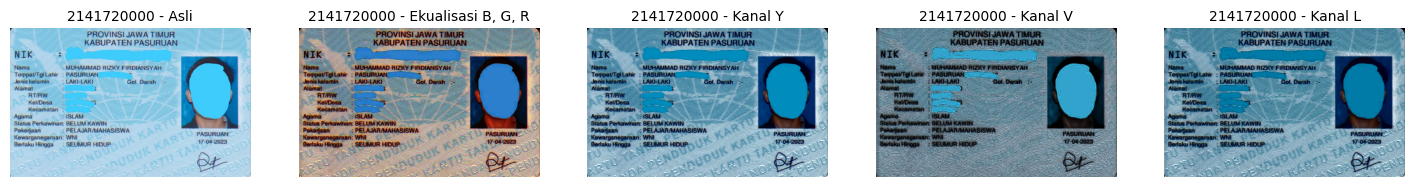


Tabel Pergeseran Warna pada ktpBlur.jpg:
Cara                    geser Hue (der)    rerata terang
Asli                               0.00            178.0
Ekualisasi B, G, R                93.62            129.4
Kanal Y                            2.70            130.8
Kanal V                            1.23            108.8
Kanal L                            3.34            119.3


In [9]:
# Ekualisasi Berwarna & Evaluasi Hue
def geser_hue(asli, hasil):
    # Hue pada OpenCV bersifat melingkar 0-179, dihitung lewat jalur terpendek
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:,:,0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:,:,0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

def evaluate_color_he(filename, NIM="2141720000"):
    bgr = cv.imread(BASE_PATH + filename)
    if bgr is None: return

    # 1. Ekualisasi B, G, R
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # 2. Kanal Y (YCrCb)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # 3. Kanal V (HSV)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # 4. Kanal L (LAB)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    # Plot 1x5
    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(f"{NIM} - {t}", fontsize=10)
        plt.axis('off')
    plt.show()

    # Evaluasi Tabel
    print(f"\nTabel Pergeseran Warna pada {filename}:")
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    for t, c in zip(judul, citra):
        hue_shift = geser_hue(bgr, c) * 2  # dikali 2 karena opencv hue 0-179
        bright_mean = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        print('%-22s %16.2f %16.1f' % (t, hue_shift, bright_mean))

# Jalankan untuk citra Anda
evaluate_color_he('ktpBlur.jpg')